In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\wasae\aeroponics-ml\data\processed\finaldataset.csv")

X = df.drop(columns=["Drain"])
y = df["Drain"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression MSE:", lr_mse)
print("Linear Regression R²:", lr_r2)


Linear Regression MSE: 0.679437432735699
Linear Regression R²: 0.0874842607525379


In [3]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", rf_mse)
print("Random Forest R²:", rf_r2)


Random Forest MSE: 0.7010802647058825
Random Forest R²: 0.05841694143343423


In [4]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MSE:", gb_mse)
print("Gradient Boosting R²:", gb_r2)


Gradient Boosting MSE: 0.6197300819617106
Gradient Boosting R²: 0.16767398051916682


In [5]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MSE": [lr_mse, rf_mse, gb_mse],
    "R2": [lr_r2, rf_r2, gb_r2]
})

results


,Model,MSE,R2
0,Linear Regression,0.679437,0.087484
1,Random Forest,0.701080,0.058417
2,Gradient Boosting,0.619730,0.167674


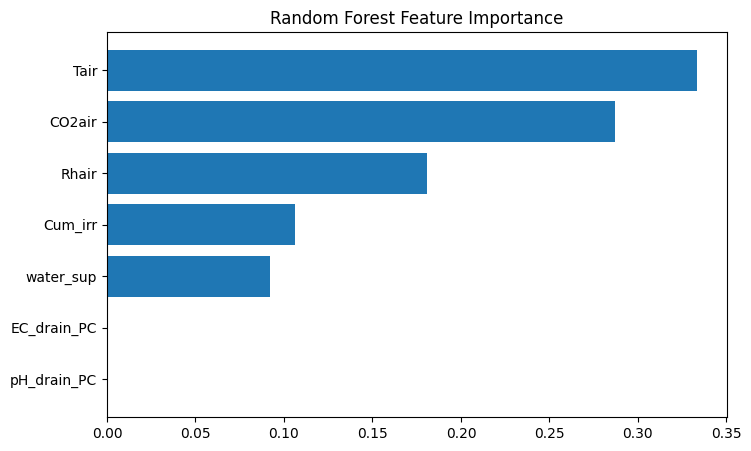

In [6]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Random Forest Feature Importance")
plt.show()


In [7]:
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_experiment("aeroponics_wastewater_prediction")

with mlflow.start_run(run_name="RandomForest"):
    mlflow.log_param("model", "RandomForest")
    mlflow.log_metric("mse", rf_mse)
    mlflow.log_metric("r2", rf_r2)
    mlflow.sklearn.log_model(rf, "model")

with mlflow.start_run(run_name="GradientBoosting"):
    mlflow.log_param("model", "GradientBoosting")
    mlflow.log_metric("mse", gb_mse)
    mlflow.log_metric("r2", gb_r2)
    mlflow.sklearn.log_model(gb, "model")


c:\Users\wasae\anaconda3\envs\aeroponics-ml\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/02/05 11:16:09 INFO mlflow.tracking.fluent: Experiment with name 'aeroponics_wastewater_prediction' does not exist. Creating a new experiment.
2026/02/05 11:16:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\wasae\anaconda3\envs\aeroponics-ml\lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercisin